# Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



## Sample Answer

1. Setting Up the Probability Space

Since the number of failures each day can only be 0, 1, 2, or 3, the natural sample space is:

$$
\Omega = \{0, 1, 2, 3\}, \qquad \mathcal{F} = \mathcal{P}(\Omega)
$$

where $\mathcal{P}(\Omega)$ denotes the collection of all subsets of $\Omega$ (the power set). This gives a complete $\sigma$-algebra on a finite space.

We assign probability to each elementary outcome as follows:

| Outcome $\omega$ | Interpretation | $P(\{\omega\})$ |
|:---:|:---|:---:|
| 0 | No failures | 0.50 |
| 1 | One failure | 0.30 |
| 2 | Two failures | 0.15 |
| 3 | Three failures | 0.05 |

For any event $A \subseteq \Omega$, the probability is obtained by summing over all outcomes in $A$:

$$
P(A) = \sum_{\omega \in A} P(\{\omega\})
$$

> **Sanity check:** $0.50 + 0.30 + 0.15 + 0.05 = 1.00$ 

2. Defining the Random Variable

We define $X : \Omega \to \mathbb{R}$ to be the identity map:

$$
X(\omega) = \omega, \qquad \omega \in \Omega
$$

In plain terms, $X$ simply records the number of transformer failures observed. The probability space and the random variable are chosen to align perfectly, so $X$ takes the value $k$ precisely when exactly $k$ failures occur.

3. Probability Mass Function

The **probability mass function (PMF)** of $X$ is:

$$
p_X(x) = P(X = x) =
\begin{cases}
0.50, & x = 0 \\
0.30, & x = 1 \\
0.15, & x = 2 \\
0.05, & x = 3 \\
0,    & \text{otherwise}
\end{cases}
$$

This fully characterises the distribution of $X$.

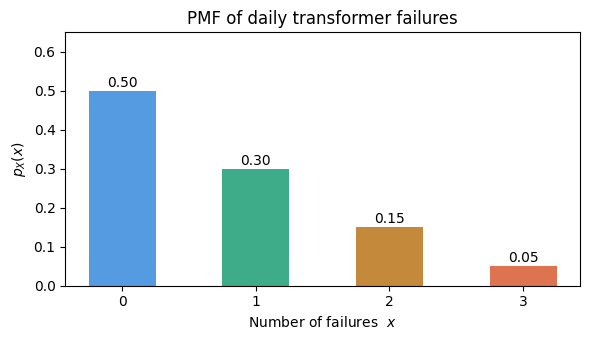

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.array([0, 1, 2, 3])
pmf    = np.array([0.50, 0.30, 0.15, 0.05])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(x_vals, pmf, width=0.5, color=['#378ADD','#1D9E75','#BA7517','#D85A30'], alpha=0.85)
ax.set_xlabel('Number of failures  $x$')
ax.set_ylabel('$p_X(x)$')
ax.set_title('PMF of daily transformer failures')
ax.set_xticks(x_vals)
ax.set_ylim(0, 0.65)
for xi, pi in zip(x_vals, pmf):
    ax.text(xi, pi + 0.01, f'{pi:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

4. Expected Value (Mean)

The **expected value** is the probability-weighted average of all possible outcomes:

$$
E[X] = \sum_{x} x \, p_X(x)
     = 0(0.50) + 1(0.30) + 2(0.15) + 3(0.05)
     = 0 + 0.30 + 0.30 + 0.15
     = 0.75
$$

On average, **0.75 transformer failures** are expected per day.

In [2]:
mean_X = np.sum(x_vals * pmf)
print(f'E[X] = {mean_X}')

E[X] = 0.75


5. Variance

We use the computational shortcut $\mathrm{Var}(X) = E[X^2] - (E[X])^2$.

**Step 1 — compute $E[X^2]$:**

$$
E[X^2] = 0^2(0.50) + 1^2(0.30) + 2^2(0.15) + 3^2(0.05)
       = 0 + 0.30 + 0.60 + 0.45
       = 1.35
$$

**Step 2 — subtract the squared mean:**

$$
\mathrm{Var}(X) = E[X^2] - (E[X])^2 = 1.35 - (0.75)^2 = 1.35 - 0.5625 = 0.7875
$$

The standard deviation is $\sigma_X = \sqrt{0.7875} \approx 0.887$, giving a sense of the typical daily deviation from the mean.

In [3]:
E_X2   = np.sum(x_vals**2 * pmf)
var_X  = E_X2 - mean_X**2
std_X  = np.sqrt(var_X)
print(f'E[X²]  = {E_X2}')
print(f'Var(X) = {var_X}')
print(f'σ(X)   = {std_X:.4f}')

E[X²]  = 1.3499999999999999
Var(X) = 0.7874999999999999
σ(X)   = 0.8874


6. Tail Probabilities

Two operationally relevant questions:

**At least one failure occurs:**

$$
P(X \ge 1) = P(X=1) + P(X=2) + P(X=3) = 0.30 + 0.15 + 0.05 = 0.50
$$

**At least two failures occur:**

$$
P(X \ge 2) = P(X=2) + P(X=3) = 0.15 + 0.05 = 0.20
$$

Equivalently, using the complement rule:

$$
P(X \ge 1) = 1 - P(X = 0) = 1 - 0.50 = 0.50
$$

In [4]:
p_geq1 = np.sum(pmf[x_vals >= 1])
p_geq2 = np.sum(pmf[x_vals >= 2])
print(f'P(X ≥ 1) = {p_geq1}')
print(f'P(X ≥ 2) = {p_geq2}')

P(X ≥ 1) = 0.49999999999999994
P(X ≥ 2) = 0.2


7. Interpretation

| Quantity | Value | What it tells us |
|:---|:---:|:---|
| $E[X]$ | 0.75 | Over many days, the average number of failures per day converges to 0.75. |
| $\mathrm{Var}(X)$ | 0.7875 | Captures the spread — how much the daily count typically fluctuates around 0.75. |
| $P(X \ge 1)$ | 0.50 | Half of all days will see at least one failure. |
| $P(X \ge 2)$ | 0.20 | One in five days will see two or more failures — a useful figure for resource planning. |

Notice that even though the *mean* is well below 1, failures are actually absent only on 50% of days. This illustrates how a right-skewed discrete distribution can have a mean that feels lower than the day-to-day reality experienced by operators.

# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.



## Sample Answer

1. Probability Space

Since the defective proportion must lie somewhere in $[0, 1]$, the appropriate sample space is the unit interval:

$$
\Omega = [0, 1], \qquad \mathcal{F} = \mathcal{B}([0,1])
$$

where $\mathcal{B}([0,1])$ is the Borel $\sigma$-algebra generated by the open subsets of $[0,1]$. This is the standard $\sigma$-algebra used for continuous models on a bounded interval.

The probability measure is defined through a density:

$$
P(A) = \int_A f(x)\, dx, \qquad A \in \mathcal{F}
$$

where

$$
f(x) =
\begin{cases}
\dfrac{1}{B(2,\,18)}\, x(1-x)^{17}, & 0 < x < 1 \\
0, & \text{otherwise}
\end{cases}
$$

and $B(\alpha, \beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1}\,dt$ is the Beta function acting as a normalising constant.

2. The Random Variable

We define $X : \Omega \to \mathbb{R}$ as the identity map on $[0,1]$:

$$
X(\omega) = \omega, \qquad \omega \in [0, 1]
$$

The value of $X$ is simply the observed defective proportion for a given batch. Choosing $X$ as the identity is the canonical construction that makes the probability space and the random variable agree exactly.

3. Probability Density Function

The PDF of $X$ is:

$$
f_X(x) =
\begin{cases}
\dfrac{1}{B(2,\,18)}\, x(1-x)^{17}, & 0 < x < 1 \\
0, & \text{otherwise}
\end{cases}
$$

This is precisely the $\mathrm{Beta}(2, 18)$ density, with shape parameters $\alpha = 2$ and $\beta = 18$. The factor $x$ reflects one "success" and $(1-x)^{17}$ reflects seventeen "failures", in the sense of the Beta–Binomial conjugate relationship.

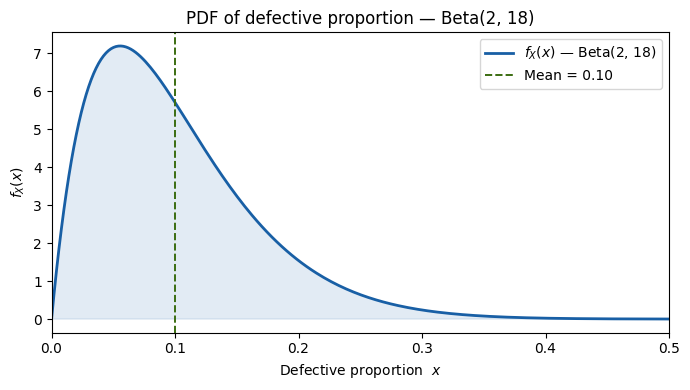

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

alpha, beta = 2, 18
X = stats.beta(alpha, beta)

x = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2, label=r'$f_X(x)$ — Beta(2, 18)')
ax.fill_between(x, X.pdf(x), alpha=0.12, color='#185FA5')
ax.axvline(X.mean(), color='#3B6D11', lw=1.4, linestyle='--', label=f'Mean = {X.mean():.2f}')
ax.set_xlabel('Defective proportion  $x$')
ax.set_ylabel('$f_X(x)$')
ax.set_title('PDF of defective proportion — Beta(2, 18)')
ax.legend()
ax.set_xlim(0, 0.5)
plt.tight_layout()
plt.show()

4. Verifying That $f_X$ Is a Valid Density

Two conditions must hold:

**Non-negativity:** For $x \in (0,1)$, both $x \ge 0$ and $(1-x)^{17} \ge 0$, and the normalising constant $B(2,18) > 0$, so $f_X(x) \ge 0$ everywhere. ✓

**Unit integral:** The integral over the whole real line reduces to:

$$
\int_{-\infty}^{\infty} f_X(x)\,dx
= \int_0^1 \frac{1}{B(2,18)}\, x(1-x)^{17}\,dx
= \frac{B(2,18)}{B(2,18)}
= 1 \checkmark
$$

The last equality uses the definition of the Beta function: $\int_0^1 t^{\alpha-1}(1-t)^{\beta-1}\,dt = B(\alpha,\beta)$, with $\alpha = 2$, $\beta = 18$.

In [6]:
from scipy.integrate import quad
from scipy.special import beta as beta_fn

integrand = lambda x: x * (1 - x)**17 / beta_fn(2, 18)
result, _ = quad(integrand, 0, 1)
print(f'Integral of f_X over [0,1] = {result:.10f}')  # should be 1.0

Integral of f_X over [0,1] = 1.0000000000


5. Expected Value

For a $\mathrm{Beta}(\alpha, \beta)$ random variable, the mean has the closed form:

$$
E[X] = \frac{\alpha}{\alpha + \beta}
$$

Substituting $\alpha = 2$, $\beta = 18$:

$$
E[X] = \frac{2}{2 + 18} = \frac{2}{20} = 0.10
$$

The long-run average defective proportion across many batches is **10%**.

In [7]:
mean = X.mean()
print(f'E[X] = {mean}')

E[X] = 0.1


6. Variance

The variance of a $\mathrm{Beta}(\alpha, \beta)$ distribution is:

$$
\mathrm{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2\,(\alpha+\beta+1)}
$$

Substituting the parameters:

$$
\mathrm{Var}(X)
= \frac{2 \times 18}{20^2 \times 21}
= \frac{36}{8400}
= \frac{3}{700}
\approx 0.00429
$$

The corresponding standard deviation is $\sigma_X = \sqrt{3/700} \approx 0.0655$, so typical batches deviate from the 10% mean by about 6.5 percentage points.

In [8]:
var = X.var()
std = X.std()
print(f'Var(X) = {var:.5f}  (exact: 3/700 = {3/700:.5f})')
print(f'σ(X)   = {std:.4f}')

Var(X) = 0.00429  (exact: 3/700 = 0.00429)
σ(X)   = 0.0655


7. Probability That the Defective Proportion Is At Most 10%

We want $P(X \le 0.10)$, which is the CDF of $X$ evaluated at $0.10$:

$$
P(X \le 0.10)
= \int_0^{0.10} \frac{1}{B(2,18)}\, x(1-x)^{17}\,dx
= I_{0.10}(2,\,18)
$$

where $I_x(\alpha, \beta)$ is the **regularised incomplete Beta function** — the standard way to express Beta CDFs.

In [9]:
p_leq_010 = X.cdf(0.10)
print(f'P(X ≤ 0.10) = {p_leq_010:.4f}')

P(X ≤ 0.10) = 0.5797


8. Probability That the Defective Proportion Lies Between 5% and 15%

For the interval probability, we subtract CDF values:

$$
P(0.05 \le X \le 0.15)
= \int_{0.05}^{0.15} \frac{1}{B(2,18)}\, x(1-x)^{17}\,dx
= I_{0.15}(2,18) - I_{0.05}(2,18)
$$

P(0.05 ≤ X ≤ 0.15) = 0.5562


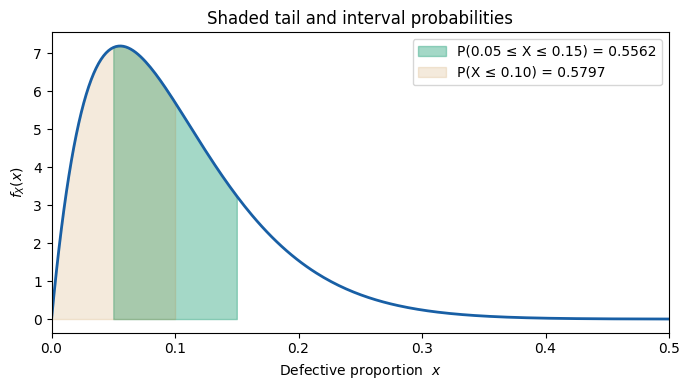

In [10]:
p_band = X.cdf(0.15) - X.cdf(0.05)
print(f'P(0.05 ≤ X ≤ 0.15) = {p_band:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2)
x_band = np.linspace(0.05, 0.15, 300)
ax.fill_between(x_band, X.pdf(x_band), alpha=0.4, color='#1D9E75',
                label=f'P(0.05 ≤ X ≤ 0.15) = {p_band:.4f}')
ax.fill_between(np.linspace(0, 0.10, 300), X.pdf(np.linspace(0, 0.10, 300)),
                alpha=0.15, color='#BA7517', label=f'P(X ≤ 0.10) = {p_leq_010:.4f}')
ax.set_xlabel('Defective proportion  $x$')
ax.set_ylabel('$f_X(x)$')
ax.set_title('Shaded tail and interval probabilities')
ax.set_xlim(0, 0.5)
ax.legend()
plt.tight_layout()
plt.show()

9. Why the Beta Distribution?

The Beta family is the natural choice for modelling a proportion or rate because:

- Its support is exactly $(0, 1)$, matching the physical constraint on any proportion.
- The two shape parameters $\alpha$ and $\beta$ offer flexible control over skewness and concentration — the distribution can be left-skewed, right-skewed, symmetric, or U-shaped.
- It arises naturally as the conjugate prior for a Binomial likelihood in Bayesian analysis, so it connects cleanly to models of pass/fail counts.

No other standard family combines these properties as cleanly for a bounded continuous quantity.

10. Summary and Interpretation

| Quantity | Value | Operational meaning |
|:---|:---:|:---|
| $E[X]$ | $0.10$ | Over many batches, the defective proportion averages 10%. |
| $\mathrm{Var}(X)$ | $\approx 0.00429$ | Measures batch-to-batch fluctuation in quality; smaller variance means more stable output. |
| $\sigma_X$ | $\approx 0.0655$ | Typical deviation from the 10% mean is about 6.5 percentage points. |
| $P(X \le 0.10)$ | (computed above) | Probability that a randomly selected batch meets or beats the average. |
| $P(0.05 \le X \le 0.15)$ | (computed above) | Probability that the batch proportion falls within $\pm 5\%$ of the mean. |

The relatively small variance ($\approx 0.0043$) indicates that the defective proportion is fairly tightly concentrated around 10%, which is reassuring from a quality-control perspective. The right skew of the Beta(2, 18) density means extreme proportions above 20–25% are very unlikely.

# Q5) Expected Project Completion Time

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


## Sample Answer

1. Support of the Random Variable

Let $X$ denote the installation time measured in hours. The expert estimates bound $X$ from below by 4 hours (the optimistic scenario) and from above by 10 hours (the pessimistic scenario), so the admissible range is:

$$
4 \leq X \leq 10
$$

Any outcome outside this interval is considered impossible under the model.

2. Probability Density Function

We model $X \sim \mathrm{Triangular}(a=4,\, b=10,\, c=6)$, where $a$ is the minimum, $b$ is the maximum, and $c$ is the mode. The general Triangular PDF is piecewise linear, rising from $a$ to $c$ and then falling from $c$ to $b$:

$$
f_X(x) =
\begin{cases}
\dfrac{2(x - a)}{(b - a)(c - a)}, & a \leq x < c \\[6pt]
\dfrac{2}{b - a}, & x = c \\[6pt]
\dfrac{2(b - x)}{(b - a)(b - c)}, & c < x \leq b \\[6pt]
0, & \text{otherwise}
\end{cases}
$$

Plugging in $a = 4$, $b = 10$, $c = 6$:

$$
f_X(x) =
\begin{cases}
\dfrac{x - 4}{6}, & 4 \leq x < 6 \\[6pt]
\dfrac{1}{3}, & x = 6 \\[6pt]
\dfrac{10 - x}{12}, & 6 < x \leq 10 \\[6pt]
0, & \text{otherwise}
\end{cases}
$$

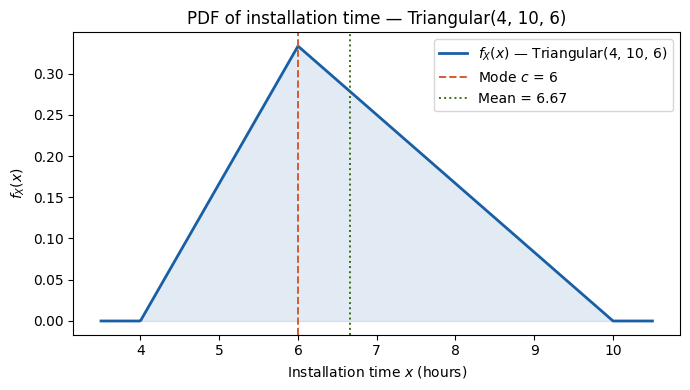

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

a, b, c = 4, 10, 6

# scipy parameterises Triangular as triang(c_scale, loc, scale)
# where c_scale = (c - a) / (b - a)
c_scale = (c - a) / (b - a)
X = stats.triang(c_scale, loc=a, scale=b - a)

x = np.linspace(3.5, 10.5, 600)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2, label=r'$f_X(x)$ — Triangular(4, 10, 6)')
ax.fill_between(x, X.pdf(x), alpha=0.12, color='#185FA5')
ax.axvline(c, color='#D85A30', lw=1.4, linestyle='--', label=f'Mode $c$ = {c}')
ax.axvline(X.mean(), color='#3B6D11', lw=1.4, linestyle=':', label=f'Mean = {X.mean():.2f}')
ax.set_xlabel('Installation time $x$ (hours)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('PDF of installation time — Triangular(4, 10, 6)')
ax.legend()
plt.tight_layout()
plt.show()

3. Verifying That $f_X$ Integrates to 1

A valid PDF must be non-negative everywhere (which is clear by inspection) and integrate to 1. We check the latter by splitting at the mode $c = 6$:

**Left piece** ($4 \leq x < 6$):

$$
\int_{4}^{6} \frac{x-4}{6}\,dx
= \frac{1}{6}\int_{4}^{6}(x-4)\,dx
= \frac{1}{6} \cdot \left[\frac{(x-4)^2}{2}\right]_4^6
= \frac{1}{6} \cdot 2
= \frac{1}{3}
$$

**Right piece** ($6 < x \leq 10$):

$$
\int_{6}^{10} \frac{10-x}{12}\,dx
= \frac{1}{12}\int_{6}^{10}(10-x)\,dx
= \frac{1}{12} \cdot \left[10x - \frac{x^2}{2}\right]_6^{10}
= \frac{1}{12} \cdot 8
= \frac{2}{3}
$$

**Total:**

$$
\int_{-\infty}^{\infty} f_X(x)\,dx = \frac{1}{3} + \frac{2}{3} = 1 \checkmark
$$

In [12]:
from scipy.integrate import quad

def f_left(x):  return (x - 4) / 6
def f_right(x): return (10 - x) / 12

left,  _ = quad(f_left,  4, 6)
right, _ = quad(f_right, 6, 10)
print(f'Left integral  = {left:.6f}   (exact: 1/3 ≈ {1/3:.6f})')
print(f'Right integral = {right:.6f}  (exact: 2/3 ≈ {2/3:.6f})')
print(f'Total          = {left + right:.6f}')

Left integral  = 0.333333   (exact: 1/3 ≈ 0.333333)
Right integral = 0.666667  (exact: 2/3 ≈ 0.666667)
Total          = 1.000000


4. Expected Value

For any Triangular$(a, b, c)$ distribution, the mean is simply the arithmetic average of the three defining parameters:

$$
E[X] = \frac{a + b + c}{3}
$$

With $a = 4$, $b = 10$, $c = 6$:

$$
E[X] = \frac{4 + 10 + 6}{3} = \frac{20}{3} \approx 6.67 \text{ hours}
$$

On average, installations are expected to take roughly **6 hours and 40 minutes**.

In [13]:
mean = X.mean()
print(f'E[X] = {mean:.4f} hours  (exact: 20/3 = {20/3:.4f})')

E[X] = 6.6667 hours  (exact: 20/3 = 6.6667)


5. Variance

The variance of a Triangular$(a, b, c)$ distribution is:

$$
\mathrm{Var}(X) = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}
$$

Substituting the values:

$$
\mathrm{Var}(X)
= \frac{16 + 100 + 36 - 40 - 24 - 60}{18}
= \frac{28}{18}
= \frac{14}{9}
\approx 1.56 \text{ hours}^2
$$

The standard deviation is $\sigma_X = \sqrt{14/9} = \tfrac{\sqrt{14}}{3} \approx 1.25$ hours, meaning typical installation times scatter about 1.25 hours either side of the mean.

In [14]:
var = X.var()
std = X.std()
print(f'Var(X) = {var:.4f}  (exact: 14/9 = {14/9:.4f})')
print(f'σ(X)   = {std:.4f} hours')

Var(X) = 1.5556  (exact: 14/9 = 1.5556)
σ(X)   = 1.2472 hours


6. Interpreting the Parameters

The three parameters have direct operational meaning:

| Parameter | Value | Meaning |
|:---:|:---:|:---|
| $a$ | 4 h | Minimum possible installation time (everything goes right) |
| $b$ | 10 h | Maximum possible installation time (worst foreseeable case) |
| $c$ | 6 h | Most likely installation time (the peak of the density) |

The mode $c = 6$ lies closer to $a$ than to $b$, producing a right-skewed distribution — the density rises quickly from 4 to 6, then falls more gradually out to 10. This reflects a realistic scenario where delays, though possible, tend to be moderate rather than extreme.

7. Why the Triangular Distribution?

The Triangular distribution is well-suited to this problem for several reasons:

- **Data-sparse settings:** When historical installation records are unavailable, expert elicitation of just three numbers (minimum, maximum, most likely) is realistic and sufficient to fully specify the model.
- **Bounded support:** Installation time cannot be negative or unbounded; the Triangular distribution is inherently confined to $[a, b]$.
- **Interpretability:** The three parameters correspond directly to practical planning concepts, making the model easy to communicate to non-statisticians.
- **PERT compatibility:** The Triangular distribution is widely used in project management frameworks (e.g. Program Evaluation and Review Technique) for exactly this kind of duration uncertainty.

8. Probability of Finishing Within 5 Hours

Since $5 < c = 6$, the point $x = 5$ falls on the rising (left) branch of the density:

$$
P(X \leq 5)
= \int_{4}^{5} \frac{x - 4}{6}\,dx
= \frac{1}{6}\int_{4}^{5}(x-4)\,dx
= \frac{1}{6} \cdot \frac{1}{2}
= \frac{1}{12}
\approx 0.0833
$$

There is only an **8.3% chance** the installation completes within 5 hours.

P(X ≤ 5) = 0.0833  (exact: 1/12 = 0.0833)


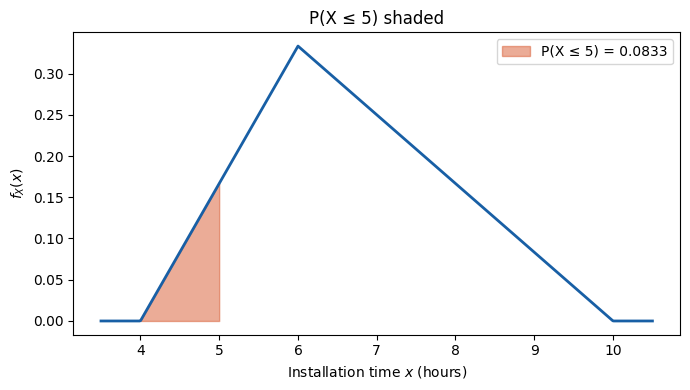

In [15]:
p_leq5 = X.cdf(5)
print(f'P(X ≤ 5) = {p_leq5:.4f}  (exact: 1/12 = {1/12:.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2)
x_shade = np.linspace(4, 5, 300)
ax.fill_between(x_shade, X.pdf(x_shade), alpha=0.5, color='#D85A30',
                label=f'P(X ≤ 5) = {p_leq5:.4f}')
ax.set_xlabel('Installation time $x$ (hours)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('P(X ≤ 5) shaded')
ax.legend()
plt.tight_layout()
plt.show()

9. Probability That Installation Takes Between 5 and 8 Hours

The interval $[5, 8]$ straddles the mode at $c = 6$, so we integrate each branch separately:

**From 5 to 6 (left branch):**

$$
\int_{5}^{6} \frac{x-4}{6}\,dx
= \frac{1}{6} \cdot \left[\frac{(x-4)^2}{2}\right]_5^6
= \frac{1}{6} \cdot \frac{3}{2}
= \frac{1}{4}
$$

**From 6 to 8 (right branch):**

$$
\int_{6}^{8} \frac{10-x}{12}\,dx
= \frac{1}{12} \cdot \left[10x - \frac{x^2}{2}\right]_6^8
= \frac{1}{12} \cdot 6
= \frac{1}{2}
$$

**Combined:**

$$
P(5 \leq X \leq 8) = \frac{1}{4} + \frac{1}{2} = \frac{3}{4}
$$

There is a **75% probability** the installation falls in the 5–8 hour window.

P(5 ≤ X ≤ 8) = 0.7500  (exact: 3/4 = 0.7500)


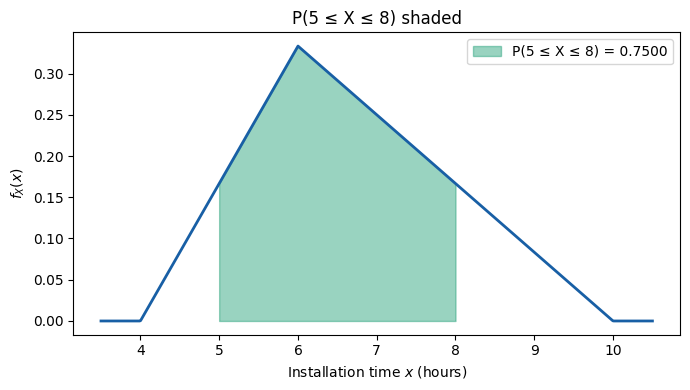

In [16]:
p_5_8 = X.cdf(8) - X.cdf(5)
print(f'P(5 ≤ X ≤ 8) = {p_5_8:.4f}  (exact: 3/4 = {3/4:.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2)
x_shade = np.linspace(5, 8, 300)
ax.fill_between(x_shade, X.pdf(x_shade), alpha=0.45, color='#1D9E75',
                label=f'P(5 ≤ X ≤ 8) = {p_5_8:.4f}')
ax.set_xlabel('Installation time $x$ (hours)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('P(5 ≤ X ≤ 8) shaded')
ax.legend()
plt.tight_layout()
plt.show()

10. Applications in Project Planning

This model has direct practical uses:

| Use case | How the model helps |
|:---|:---|
| **Deadline risk assessment** | Compute $P(X > t)$ for any deadline $t$ to quantify the chance of overrunning. |
| **Buffer sizing** | Find the $p$-th percentile of $X$ (e.g. the 90th) to set conservative time allocations. |
| **Staffing decisions** | Longer expected durations may trigger the need for additional personnel on standby. |
| **Sensitivity analysis** | Vary $a$, $b$, $c$ to see how changes in expert estimates propagate to schedule risk. |
| **Monte Carlo simulation** | Draw many samples from $X$ as an input to a larger project simulation involving multiple dependent tasks. |

> **Example:** $P(X \leq 8) = P(X \leq 5) + P(5 \leq X \leq 8) = \frac{1}{12} + \frac{3}{4} = \frac{5}{6} \approx 83.3\%$. If management wants at least an 83% on-time probability, scheduling a maximum of 8 hours for the installation is sufficient under this model.

In [17]:
# Summary table
import pandas as pd

summary = pd.DataFrame({
    'Quantity': ['Minimum (a)', 'Maximum (b)', 'Mode (c)', 'E[X]', 'Var(X)', 'σ(X)',
                 'P(X ≤ 5)', 'P(5 ≤ X ≤ 8)', 'P(X ≤ 8)'],
    'Value': [4, 10, 6,
              round(mean, 4), round(var, 4), round(std, 4),
              round(p_leq5, 4), round(p_5_8, 4), round(X.cdf(8), 4)],
    'Exact': ['4', '10', '6',
              '20/3', '14/9', '√14/3',
              '1/12', '3/4', '5/6']
})
print(summary.to_string(index=False))

    Quantity   Value Exact
 Minimum (a)  4.0000     4
 Maximum (b) 10.0000    10
    Mode (c)  6.0000     6
        E[X]  6.6667  20/3
      Var(X)  1.5556  14/9
        σ(X)  1.2472 √14/3
    P(X ≤ 5)  0.0833  1/12
P(5 ≤ X ≤ 8)  0.7500   3/4
    P(X ≤ 8)  0.8333   5/6


# Q6) Expected Project Completion Time Using PERT

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Show that the expectation $E[X]$ is

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


## Sample Answer

1. Parameters and Shape Coefficients

The three expert inputs are:

$$
a = 8 \quad (\text{optimistic}), \qquad
b = 20 \quad (\text{pessimistic}), \qquad
c = 11 \quad (\text{most likely})
$$

The PERT method converts these into Beta shape parameters by weighting the mode four times more heavily than the endpoints:

$$
\alpha = 1 + 4\left(\frac{c - a}{b - a}\right)
= 1 + 4\left(\frac{11 - 8}{20 - 8}\right)
= 1 + 4\left(\frac{3}{12}\right)
= 1 + 1 = 2
$$

$$
\beta = 1 + 4\left(\frac{b - c}{b - a}\right)
= 1 + 4\left(\frac{20 - 11}{20 - 8}\right)
= 1 + 4\left(\frac{9}{12}\right)
= 1 + 3 = 4
$$

Note that $\alpha < \beta$, which already tells us the distribution will be right-skewed — the density rises steeply near the minimum and tapers more gently toward the maximum.

In [18]:
a, b, c = 8, 20, 11

alpha = 1 + 4 * (c - a) / (b - a)
beta  = 1 + 4 * (b - c) / (b - a)

print(f'a = {a},  b = {b},  c = {c}')
print(f'α = {alpha},  β = {beta}')

a = 8,  b = 20,  c = 11
α = 2.0,  β = 4.0


2. Support

Because $X$ represents task duration, it is physically bounded by the expert-supplied limits:

$$
8 \leq X \leq 20
$$

Durations outside this interval are assigned zero probability.

3. Probability Density Function

The PERT density is a Beta$(\alpha, \beta)$ distribution rescaled to $[a, b]$:

$$
f_X(x)
= \frac{(x - a)^{\alpha-1}\,(b - x)^{\beta-1}}{B(\alpha,\,\beta)\,(b-a)^{\alpha+\beta-1}},
\qquad a \leq x \leq b
$$

Substituting $\alpha = 2$, $\beta = 4$, $a = 8$, $b = 20$:

$$
f_X(x)
= \frac{(x-8)\,(20-x)^3}{B(2,4)\cdot 12^5},
\qquad 8 \leq x \leq 20
$$

The normalising constant $B(2, 4)$ evaluates using the Gamma function:

$$
B(2,4)
= \frac{\Gamma(2)\,\Gamma(4)}{\Gamma(6)}
= \frac{1! \cdot 3!}{5!}
= \frac{1 \cdot 6}{120}
= \frac{1}{20}
$$

So the density simplifies to:

$$
f_X(x) = \frac{20\,(x-8)\,(20-x)^3}{12^5}, \qquad 8 \leq x \leq 20, \qquad f_X(x) = 0 \text{ otherwise}
$$

B(2, 4) = 0.050000  (exact: 1/20 = 0.050000)


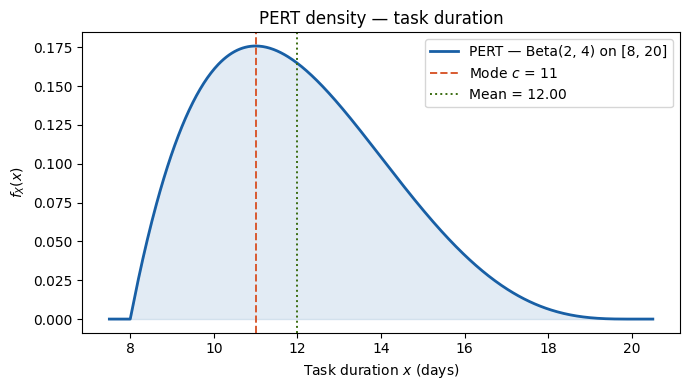

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma, beta as beta_fn

B_24 = beta_fn(alpha, beta)
print(f'B(2, 4) = {B_24:.6f}  (exact: 1/20 = {1/20:.6f})')

# scipy parameterises scaled Beta as beta(a, b, loc, scale)
X = stats.beta(alpha, beta, loc=a, scale=b - a)

x = np.linspace(7.5, 20.5, 600)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2, label=r'PERT — Beta(2, 4) on [8, 20]')
ax.fill_between(x, X.pdf(x), alpha=0.12, color='#185FA5')
ax.axvline(c,       color='#D85A30', lw=1.4, linestyle='--', label=f'Mode $c$ = {c}')
ax.axvline(X.mean(), color='#3B6D11', lw=1.4, linestyle=':', label=f'Mean = {X.mean():.2f}')
ax.set_xlabel('Task duration $x$ (days)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('PERT density — task duration')
ax.legend()
plt.tight_layout()
plt.show()

4. Probability Space

A formal probability space supporting this model is:

$$
\Omega = [8, 20], \qquad \mathcal{F} = \mathcal{B}([8, 20])
$$

where $\mathcal{B}([8, 20])$ is the Borel $\sigma$-algebra on the interval. The probability of any measurable event $A \in \mathcal{F}$ is:

$$
P(A) = \int_A f_X(x)\, dx
$$

5. The Random Variable

We define $X : \Omega \to \mathbb{R}$ as the identity on $[8, 20]$:

$$
X(\omega) = \omega, \qquad \omega \in [8, 20]
$$

The sample point $\omega$ is directly the observed task duration, so the random variable and the probability space coincide without any further mapping.

6. Expected Value — Derivation of the PERT Mean Formula

Starting from the definition of expectation and substituting the scaled Beta density:

$$
E[X] = \int_a^b x \cdot \frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}\, dx
$$

**Change of variable:** let $t = \dfrac{x - a}{b - a}$, so $x = a + (b-a)t$ and $dx = (b-a)\,dt$. The integration limits become $[0, 1]$ and the factors transform as $(x-a) = (b-a)t$, $(b-x) = (b-a)(1-t)$. After substitution, powers of $(b-a)$ cancel exactly, leaving:

$$
E[X] = \frac{1}{B(\alpha,\beta)}\int_0^1 \bigl[a\, t^{\alpha-1}(1-t)^{\beta-1} + (b-a)\,t^{\alpha}(1-t)^{\beta-1}\bigr]\,dt
$$

Recognising both integrals as Beta functions:

$$
E[X] = a + (b-a)\,\frac{B(\alpha+1,\beta)}{B(\alpha,\beta)}
$$

Using the identity $\dfrac{B(\alpha+1,\beta)}{B(\alpha,\beta)} = \dfrac{\alpha}{\alpha+\beta}$ (which follows directly from $\Gamma(\alpha+1) = \alpha\,\Gamma(\alpha)$):

$$
E[X] = a + (b-a)\,\frac{\alpha}{\alpha+\beta}
$$

Since $\alpha + \beta = 6$ for any valid PERT parameterisation (the $4 \times$ weighting is chosen precisely to produce this), and $\alpha = 1 + 4\dfrac{c-a}{b-a}$, substituting gives the celebrated **PERT mean**:

$$
\boxed{E[X] = \frac{a + 4c + b}{6}}
$$

Numerically:

$$
E[X] = \frac{8 + 4(11) + 20}{6} = \frac{72}{6} = 12 \text{ days}
$$

In [20]:
mean_formula = (a + 4*c + b) / 6
mean_scipy   = X.mean()
print(f'PERT mean (formula) = {mean_formula:.4f}')
print(f'PERT mean (scipy)   = {mean_scipy:.4f}')

PERT mean (formula) = 12.0000
PERT mean (scipy)   = 12.0000


7. Variance

The PERT variance is approximated by:

$$
\mathrm{Var}(X) = \frac{(E[X] - a)(b - E[X])}{7}
$$

Substituting $E[X] = 12$, $a = 8$, $b = 20$:

$$
\mathrm{Var}(X) = \frac{(12-8)(20-12)}{7} = \frac{4 \times 8}{7} = \frac{32}{7} \approx 4.57 \text{ days}^2
$$

> The divisor 7 (rather than 6) is an empirical correction that makes the PERT variance a better approximation to the true scaled Beta variance when the mode is not centred.

In [21]:
var_formula = (mean_formula - a) * (b - mean_formula) / 7
var_scipy   = X.var()
print(f'Var(X) — PERT formula = {var_formula:.4f}  (exact: 32/7 = {32/7:.4f})')
print(f'Var(X) — true Beta    = {var_scipy:.4f}')

Var(X) — PERT formula = 4.5714  (exact: 32/7 = 4.5714)
Var(X) — true Beta    = 4.5714


8. Standard Deviation and the Rule of Thumb

The standard deviation follows directly:

$$
\sigma = \sqrt{\mathrm{Var}(X)} = \sqrt{\frac{32}{7}} \approx 2.14 \text{ days}
$$

A common back-of-envelope approximation used in PERT scheduling treats the range as covering roughly six standard deviations:

$$
\sigma \approx \frac{b - a}{6} = \frac{20 - 8}{6} = 2 \text{ days}
$$

This rule-of-thumb value of 2 is close to the more precise figure of 2.14, confirming the approximation is serviceable for quick planning calculations.

In [22]:
import numpy as np

std_formula  = np.sqrt(var_formula)
std_thumb    = (b - a) / 6
print(f'σ (PERT formula)   = {std_formula:.4f} days')
print(f'σ (rule of thumb)  = {std_thumb:.4f} days')

σ (PERT formula)   = 2.1381 days
σ (rule of thumb)  = 2.0000 days


9. PERT vs Triangular — A Comparison

Both distributions use the same three inputs $(a, b, c)$, but the Triangular model weights all three equally whereas the PERT model gives four times the weight to the mode $c$. The practical consequences are:

| Quantity | Triangular$(8, 20, 11)$ | PERT$(8, 20, 11)$ |
|:---|:---:|:---:|
| Mean | $\dfrac{8+20+11}{3} = 13$ | $\dfrac{8+4(11)+20}{6} = 12$ |
| Variance | $\dfrac{49}{6} \approx 8.17$ | $\dfrac{32}{7} \approx 4.57$ |
| Standard deviation | $\approx 2.86$ | $\approx 2.14$ |
| Shape | Piecewise linear, sharp peak at mode | Smooth unimodal curve, mode weighted more strongly |

The PERT mean (12 days) lies closer to the mode (11 days) than the Triangular mean (13 days) does, because the PERT formula explicitly up-weights expert knowledge about the most likely outcome. The smaller PERT variance reflects the same: the density is more concentrated around the mode.

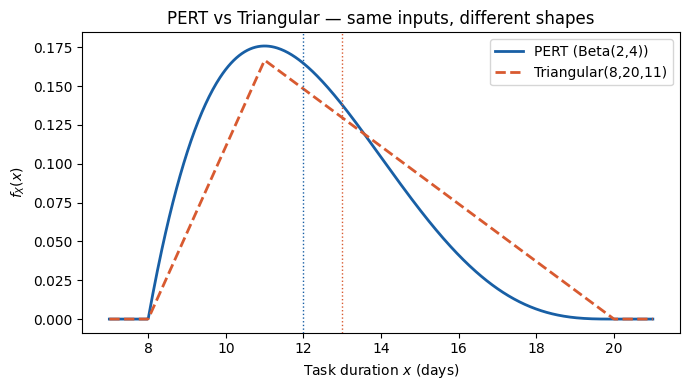

Triangular: mean = 13.0000, var = 6.5000, σ = 2.5495
PERT:       mean = 12.0000,     var = 4.5714,  σ = 2.1381


In [23]:
# Triangular via scipy
c_scale = (c - a) / (b - a)
X_tri   = stats.triang(c_scale, loc=a, scale=b - a)

x_plot = np.linspace(7, 21, 600)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_plot, X.pdf(x_plot),     color='#185FA5', lw=2, label='PERT (Beta(2,4))')
ax.plot(x_plot, X_tri.pdf(x_plot), color='#D85A30', lw=2, linestyle='--', label='Triangular(8,20,11)')
ax.axvline(X.mean(),     color='#185FA5', lw=1, linestyle=':')
ax.axvline(X_tri.mean(), color='#D85A30', lw=1, linestyle=':')
ax.set_xlabel('Task duration $x$ (days)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('PERT vs Triangular — same inputs, different shapes')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Triangular: mean = {X_tri.mean():.4f}, var = {X_tri.var():.4f}, σ = {X_tri.std():.4f}')
print(f'PERT:       mean = {X.mean():.4f},     var = {X.var():.4f},  σ = {X.std():.4f}')

10. Interpretation and Planning Applications

The estimated quantities have direct operational meaning:

| Quantity | Value | Interpretation |
|:---|:---:|:---|
| $a$ | 8 days | Shortest plausible duration — everything proceeds without issue |
| $b$ | 20 days | Longest plausible duration — worst foreseeable delays |
| $c$ | 11 days | Single most likely duration, as judged by the expert |
| $E[X]$ | 12 days | Expected task duration for scheduling purposes |
| $\sigma$ | ≈ 2.14 days | Typical deviation around the mean — a measure of scheduling risk |

**Practical uses:**

- **Deadline risk:** Compute $P(X > t)$ for a given project deadline $t$ to quantify the probability of overrunning.
- **Buffer allocation:** Use upper percentiles (e.g. the 90th) to set conservative completion targets with an explicit confidence level.
- **Critical path analysis:** Feed $E[X]$ and $\mathrm{Var}(X)$ into a network model to propagate uncertainty across dependent tasks.
- **Contingency planning:** The gap between the mean (12 days) and the worst case (20 days) signals how much buffer might be needed if the task unexpectedly runs long.

In [24]:
import pandas as pd

# Deadline exceedance probabilities
deadlines = [10, 12, 14, 16, 18]
rows = [{'Deadline (days)': t,
         'P(X ≤ t) — PERT': round(X.cdf(t), 4),
         'P(X > t) — PERT': round(1 - X.cdf(t), 4)} for t in deadlines]

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 Deadline (days)  P(X ≤ t) — PERT  P(X > t) — PERT
              10           0.1962           0.8038
              12           0.5391           0.4609
              14           0.8125           0.1875
              16           0.9547           0.0453
              18           0.9967           0.0033


# Q7) If the PERT Expectation is to Match Our Intuition

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

## Sample Answer



The given values are:

$$
a = 5 \quad (\text{minimum}), \qquad c = 11 \quad (\text{most likely}), \qquad b = \text{unknown}
$$

The PERT mean formula weights the mode four times more heavily than the endpoints:

$$
E[X] = \frac{a + 4c + b}{6}
$$

We require $E[X] = c$, and our goal is to find $b$ and understand what this constraint implies for the variance.

1 — Finding the Maximum Time $b$

Setting $E[X] = c$ in the mean formula:

$$
\frac{a + 4c + b}{6} = c
$$

Multiplying both sides by 6:

$$
a + 4c + b = 6c
$$

Rearranging:

$$
a + b = 2c \implies b = 2c - a
$$

This is a neat result: the constraint $E[X] = c$ forces the minimum and maximum to be **symmetric about the mode**. The mode sits exactly halfway between $a$ and $b$.

Substituting $a = 5$ and $c = 11$:

$$
b = 2(11) - 5 = 22 - 5 = \boxed{17}
$$

In [25]:
a, c = 5, 11
b = 2*c - a

print(f'a = {a},  c = {c}')
print(f'b = 2c - a = 2({c}) - {a} = {b}')

# Verify
mean_check = (a + 4*c + b) / 6
print(f'\nVerification: E[X] = ({a} + 4×{c} + {b}) / 6 = {a + 4*c + b} / 6 = {mean_check}')
print(f'E[X] == c: {mean_check == c}')

a = 5,  c = 11
b = 2c - a = 2(11) - 5 = 17

Verification: E[X] = (5 + 4×11 + 17) / 6 = 66 / 6 = 11.0
E[X] == c: True


2 — What Happens to the Variance?

The PERT variance approximation is:

$$
\mathrm{Var}(X) = \frac{(E[X] - a)(b - E[X])}{7}
$$

Imposing $E[X] = c$:

$$
\mathrm{Var}(X) = \frac{(c - a)(b - c)}{7}
$$

Now substitute $b = 2c - a$, which gives $b - c = c - a$:

$$
\mathrm{Var}(X) = \frac{(c - a)^2}{7}
$$

Since $b - a = 2(c - a)$ under our constraint, this is equivalently:

$$
\mathrm{Var}(X) = \frac{(b - a)^2}{28}
$$

**Key insight:** When $E[X] = c$, the mode sits exactly at the midpoint of $[a, b]$. The distribution becomes symmetric around $c$, and the variance depends only on the squared half-range $(c - a)^2$. The larger the gap between the minimum and the mode, the more spread the distribution.

Substituting $a = 5$, $c = 11$:

$$
\mathrm{Var}(X) = \frac{(11 - 5)^2}{7} = \frac{36}{7} \approx 5.14 \text{ days}^2, \qquad \sigma \approx 2.27 \text{ days}
$$

In [26]:
import numpy as np

var_formula = (c - a)**2 / 7
std_formula = np.sqrt(var_formula)

print(f'Var(X) = (c - a)² / 7 = ({c} - {a})² / 7 = {(c-a)**2} / 7 = {var_formula:.4f}')
print(f'σ(X)   = √(Var(X)) = {std_formula:.4f} days')
print(f'\nAlternate form: (b - a)² / 28 = {b - a}² / 28 = {(b-a)**2} / 28 = {(b-a)**2/28:.4f}')

Var(X) = (c - a)² / 7 = (11 - 5)² / 7 = 36 / 7 = 5.1429
σ(X)   = √(Var(X)) = 2.2678 days

Alternate form: (b - a)² / 28 = 12² / 28 = 144 / 28 = 5.1429


Visualisation — The Symmetric PERT Density

With $b = 2c - a$, the PERT shape parameters become:

$$
\alpha = 1 + 4\left(\frac{c - a}{b - a}\right) = 1 + 4\left(\frac{1}{2}\right) = 3
$$

$$
\beta = 1 + 4\left(\frac{b - c}{b - a}\right) = 1 + 4\left(\frac{1}{2}\right) = 3
$$

When $E[X] = c$, the constraint forces $\alpha = \beta = 3$ — a symmetric Beta(3, 3) distribution rescaled to $[a, b]$. This is always the case, regardless of the specific values of $a$, $b$, and $c$.

α = 3.0,  β = 3.0  → symmetric Beta(3, 3)


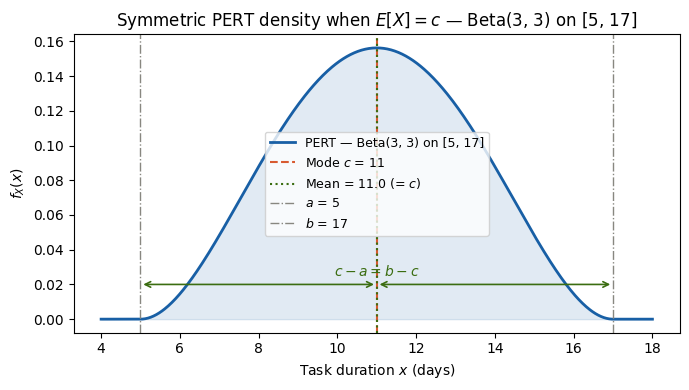

In [27]:
import matplotlib.pyplot as plt
from scipy import stats

alpha = 1 + 4*(c - a)/(b - a)
beta  = 1 + 4*(b - c)/(b - a)
print(f'α = {alpha},  β = {beta}  → symmetric Beta(3, 3)')

X = stats.beta(alpha, beta, loc=a, scale=b - a)

x = np.linspace(4, 18, 600)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, X.pdf(x), color='#185FA5', lw=2, label='PERT — Beta(3, 3) on [5, 17]')
ax.fill_between(x, X.pdf(x), alpha=0.13, color='#185FA5')

ax.axvline(c,         color='#D85A30', lw=1.5, linestyle='--', label=f'Mode $c$ = {c}')
ax.axvline(X.mean(),  color='#3B6D11', lw=1.5, linestyle=':',  label=f'Mean = {X.mean():.1f} (= $c$)')
ax.axvline(a,         color='#888780', lw=1,   linestyle='-.',  label=f'$a$ = {a}')
ax.axvline(b,         color='#888780', lw=1,   linestyle='-.',  label=f'$b$ = {b}')

# annotate symmetry
ax.annotate('', xy=(c + (c-a), 0.02), xytext=(c, 0.02),
            arrowprops=dict(arrowstyle='<->', color='#3B6D11', lw=1.2))
ax.annotate('', xy=(c - (c-a), 0.02), xytext=(c, 0.02),
            arrowprops=dict(arrowstyle='<->', color='#3B6D11', lw=1.2))
ax.text(c, 0.025, r'$c - a = b - c$', ha='center', fontsize=10, color='#3B6D11')

ax.set_xlabel('Task duration $x$ (days)')
ax.set_ylabel('$f_X(x)$')
ax.set_title('Symmetric PERT density when $E[X] = c$ — Beta(3, 3) on [5, 17]')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()